# House Price Prediction using Machine Learning
This notebook demonstrates how to predict house prices using various machine learning techniques. We'll go through the complete data science pipeline from data loading to model deployment.

In [29]:
#Import Libraries
!pip install numpy pandas matplotlib seaborn scikit-learn jupyter


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


In [31]:
#Configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

Random_State = 42
CSV_PATH = 'housing.csv' 
TARGET_COLUMN = 'median_house_value'

In [32]:
df = pd.read_csv(CSV_PATH)

In [33]:
print("Dataset Shape:", df.shape)

Dataset Shape: (20640, 10)


In [34]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


In [35]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

#Column Details 
1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [36]:
#BASIC DATASET OVERVIEW
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [37]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Target Column:", TARGET_COLUMN)
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)



Target Column: median_house_value
Numerical Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical Columns: ['ocean_proximity']


/tmp/ipykernel_39067/1318056334.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [38]:
#Missinf values analysis
print("Missing Values in Each Column:")
print(df.isna().sum())

Missing Values in Each Column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [39]:
#check presence of encoded missing valaues 
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.370    128
-118.250    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
34.110    162
33.980    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

In [40]:
#Duplicate rows analysis
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print(f"Number of duplicate rows: {num_duplicates}")



Number of duplicate rows: 0


In [41]:
#Descriptive Stat
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.000,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.540,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.330,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.000,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.000,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000


In [42]:
#Descriptive Stat
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


*DATA VISUALIZATION*

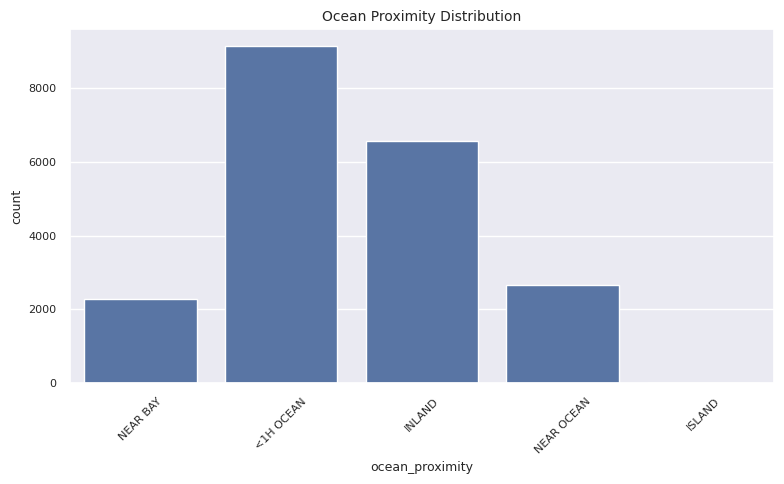

In [43]:
#CountPlot for categorical 
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='ocean_proximity')
plt.title('Ocean Proximity Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

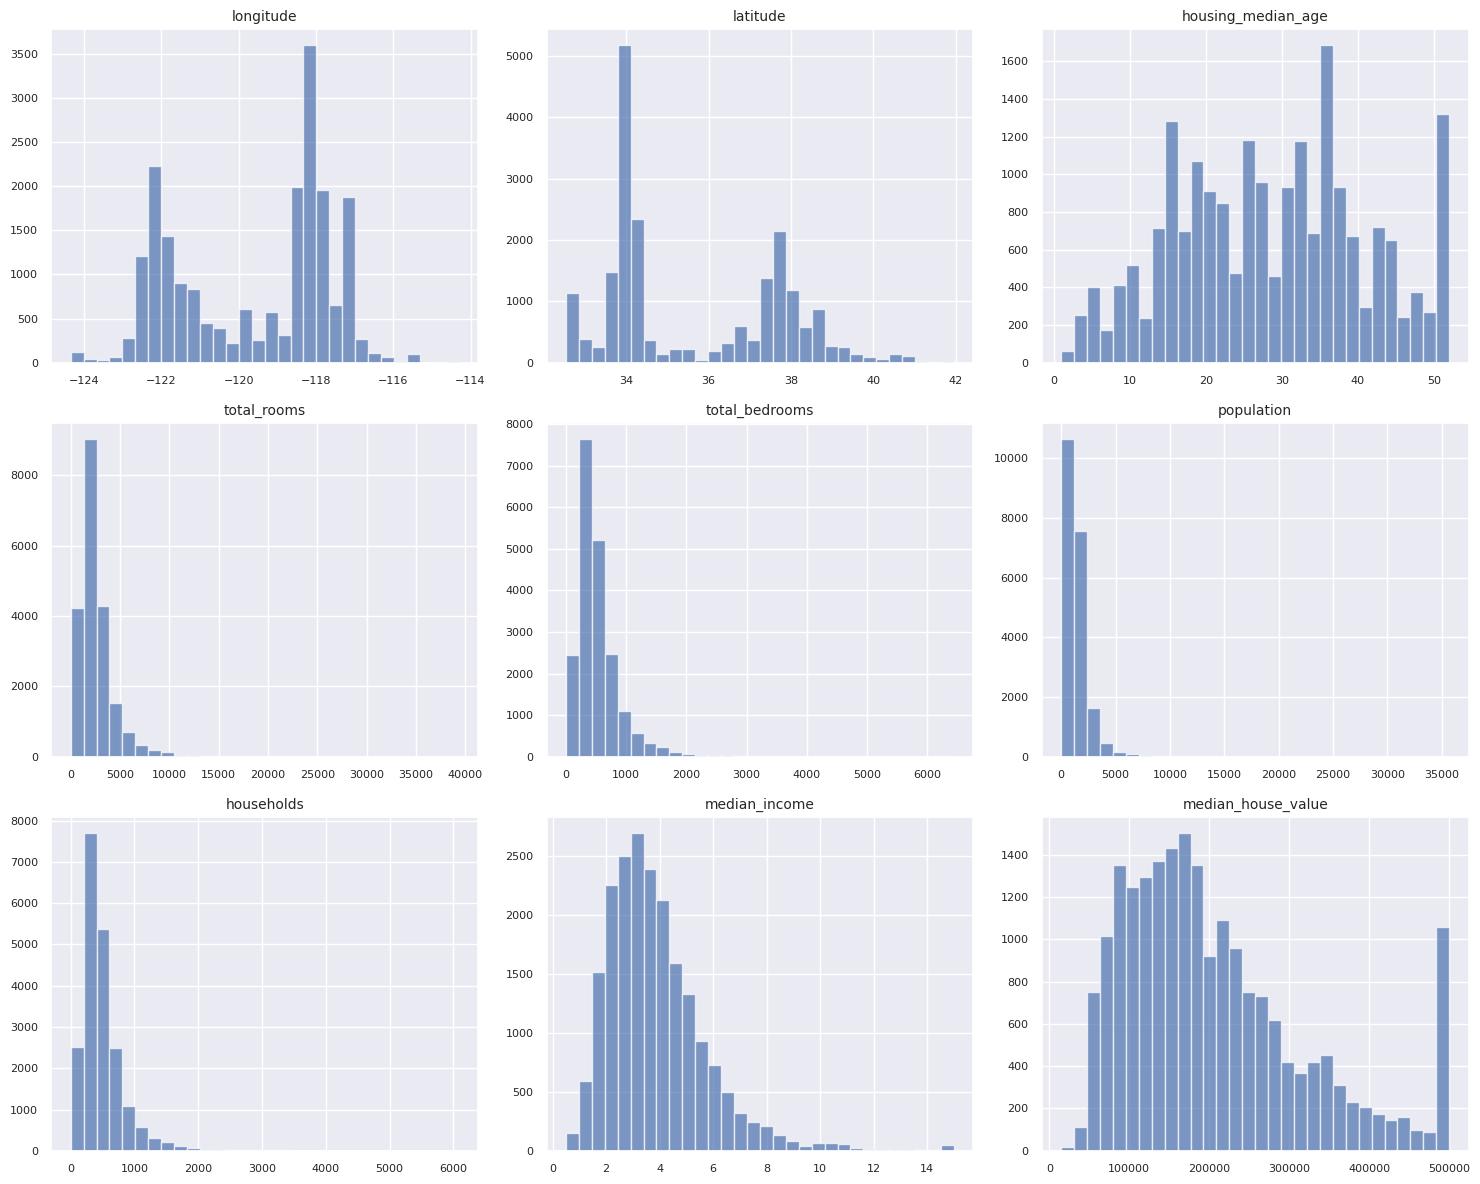

In [44]:
#Histogram for numerical features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, alpha=0.7)
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

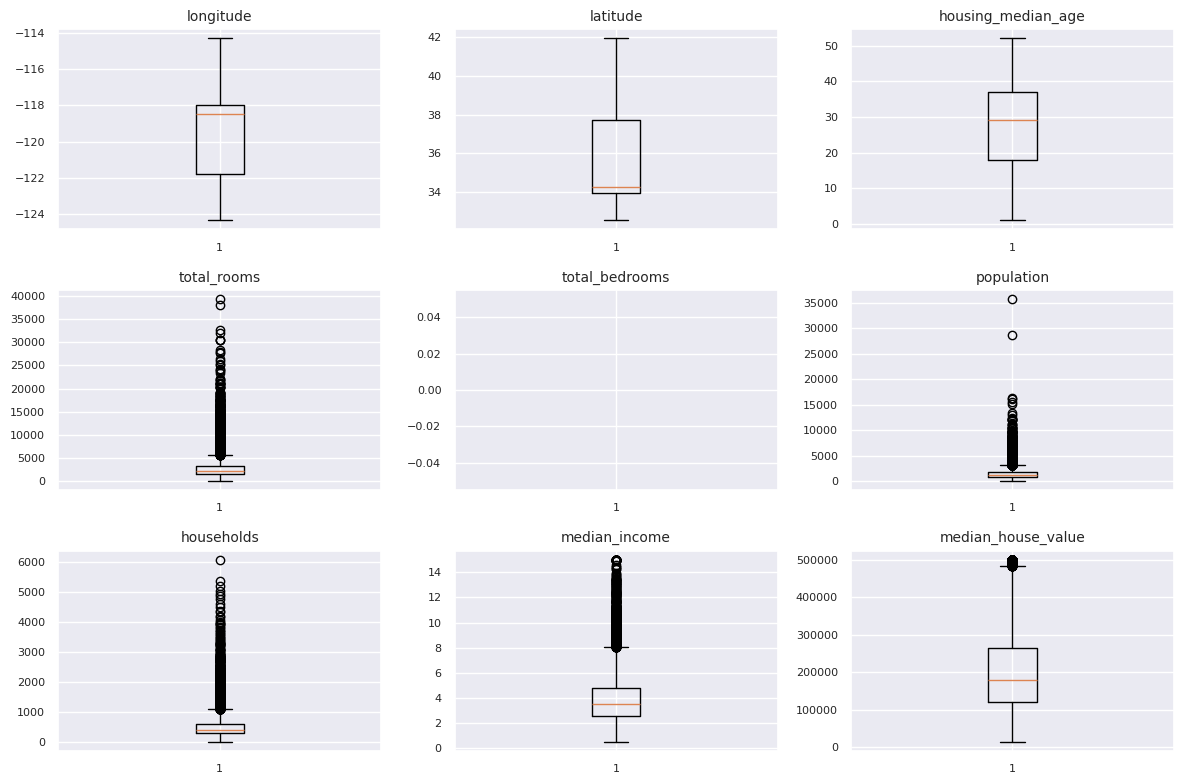

In [45]:
#Boxplot for outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

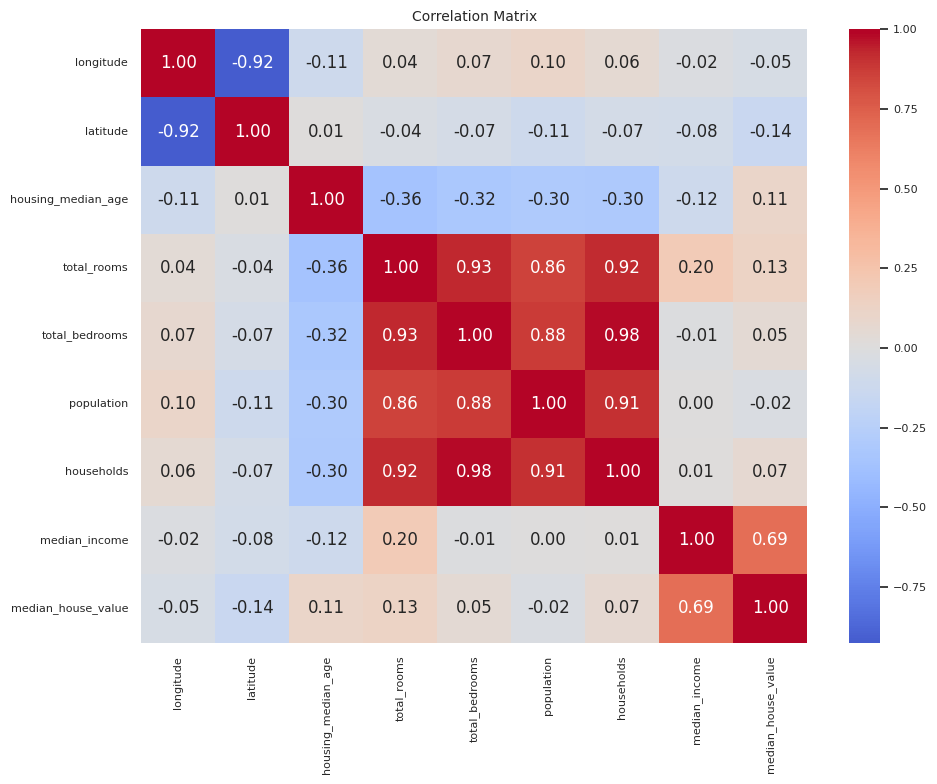

In [46]:
#Correlation matrix
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## DATA PREPROCESSING

In [47]:
#Check missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Total missing: 207


In [57]:
#Handle missing values properly
df = df.copy()  # Fix chained assignment warning
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

#Create new features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['population_per_household'] = df['population'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

print("New features created")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

New features created
Shape: (20640, 14)
Missing values: 0


In [56]:
#Check for NaN and infinite values
print("NaN values after feature engineering:")
print(df.isnull().sum())
print("\nInfinite values:")
print(df.isin([np.inf, -np.inf]).sum())

NaN values after feature engineering:
longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms              207
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
population_per_household      0
bedrooms_per_room           207
ocean_proximity_encoded       0
dtype: int64

Infinite values:
longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms              0
population                  0
households                  0
median_income               0
median_house_value          0
ocean_proximity             0
rooms_per_household         0
population_per_household    0
bedrooms_per_room           0
ocean_proximity_encoded     0
dtype: int64


In [58]:
#Encode categorical features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['ocean_proximity_encoded'] = le.fit_transform(df['ocean_proximity'])

print("Encoding mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

Encoding mapping:
<1H OCEAN: 0
INLAND: 1
ISLAND: 2
NEAR BAY: 3
NEAR OCEAN: 4


## MODEL TRAINING

In [59]:
#Prepare features and target
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['median_house_value', 'ocean_proximity'], axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (16512, 12)
Test set: (4128, 12)


In [60]:
#Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled")

Features scaled


In [61]:
#Train models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

#Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained")

Models trained


## MODEL EVALUATION

In [62]:
#Evaluate models
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

#Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression:")
print(f"RMSE: ${lr_rmse:,.2f}")
print(f"R² Score: {lr_r2:.4f}")

print("\nRandom Forest:")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R² Score: {rf_r2:.4f}")

Linear Regression:
RMSE: $74,267.08
R² Score: 0.5791

Random Forest:
RMSE: $50,615.84
R² Score: 0.8045


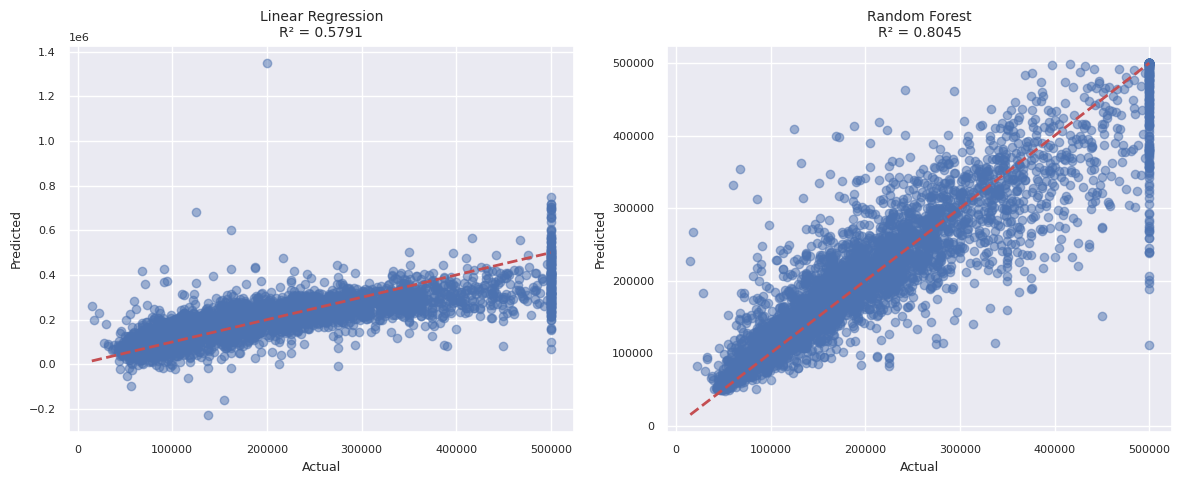

In [66]:
#Prediction vs Actual plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Linear Regression\nR² = {lr_r2:.4f}')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Random Forest\nR² = {rf_r2:.4f}')

plt.tight_layout()
plt.show()

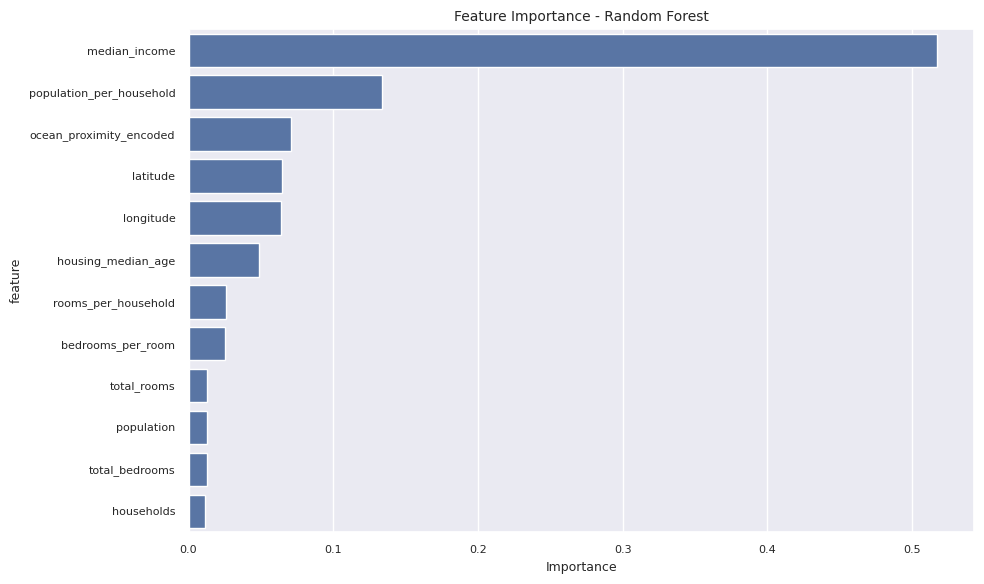

                     feature  importance
7              median_income       0.517
9   population_per_household       0.134
11   ocean_proximity_encoded       0.071
1                   latitude       0.065
0                  longitude       0.064
2         housing_median_age       0.049
8        rooms_per_household       0.026
10         bedrooms_per_room       0.025
3                total_rooms       0.013
5                 population       0.013
4             total_bedrooms       0.013
6                 households       0.011


In [67]:
#Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(feature_importance)

## PREDICTIONS

In [68]:
#Sample prediction
sample_data = X_test.iloc[0:5]
sample_actual = y_test.iloc[0:5]

rf_sample_pred = rf_model.predict(sample_data)

results_df = pd.DataFrame({
    'Actual': sample_actual.values,
    'Predicted': rf_sample_pred,
    'Difference': sample_actual.values - rf_sample_pred
})

print("Sample Predictions (Random Forest):")
print(results_df)

Sample Predictions (Random Forest):
      Actual  Predicted  Difference
0  47700.000  49094.000   -1394.000
1  45800.000 107172.000  -61372.000
2 500001.000 471367.480   28633.520
3 218600.000 262850.000  -44250.000
4 278000.000 228122.000   49878.000


## SAVE MODEL FOR DEPLOYMENT

In [75]:
#Save model and scaler
import pickle

#Save the best model
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

#Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

#Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model, scaler, and encoder saved successfully!")

Model, scaler, and encoder saved successfully!


## MODEL IMPROVEMENT

In [69]:
#1. Hyperparameter tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Starting hyperparameter tuning...")
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42), 
    param_grid, 
    cv=3, 
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV score: {np.sqrt(-rf_grid.best_score_):.2f}")

Starting hyperparameter tuning...
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV score: 51190.61


In [70]:
#2. Advanced models
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

#XGBoost alternative - Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

#Support Vector Regression 
svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
svr_model.fit(X_train_scaled, y_train)

print("Advanced models trained")

Advanced models trained


In [71]:
#3. Ensemble method - Voting Regressor
from sklearn.ensemble import VotingRegressor

#Create ensemble
ensemble = VotingRegressor([
    ('rf', rf_grid.best_estimator_),
    ('gb', gb_model),
    ('lr', lr_model)
])

ensemble.fit(X_train_scaled, y_train)
print("Ensemble model trained")

Ensemble model trained


In [72]:
#4. Compare all models
models = {
    'Random Forest (Original)': rf_model,
    'Random Forest (Tuned)': rf_grid.best_estimator_,
    'Gradient Boosting': gb_model,
    'SVR': svr_model,
    'Ensemble': ensemble
}

results = []
for name, model in models.items():
    if name in ['SVR', 'Ensemble']:
        pred = model.predict(X_test_scaled)
    else:
        pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    results.append({
        'Model': name,
        'RMSE': f'${rmse:,.2f}',
        'R² Score': f'{r2:.4f}'
    })

results_df = pd.DataFrame(results)
print("Model Comparison:")
print(results_df.to_string(index=False))

Model Comparison:
                   Model       RMSE R² Score
Random Forest (Original) $50,615.84   0.8045
   Random Forest (Tuned) $49,935.20   0.8097
       Gradient Boosting $54,012.13   0.7774
                     SVR $96,778.29   0.2853
                Ensemble $55,080.90   0.7685


In [73]:
#5. Feature selection and engineering
from sklearn.feature_selection import SelectKBest, f_regression

#Select top 8 features
selector = SelectKBest(score_func=f_regression, k=8)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print("Selected features:", list(selected_features))

#Train model with selected features
rf_selected = RandomForestRegressor(n_estimators=200, random_state=42)
rf_selected.fit(X_train_selected, y_train)

pred_selected = rf_selected.predict(X_test_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test, pred_selected))
r2_selected = r2_score(y_test, pred_selected)

print(f"Feature Selection Model - RMSE: ${rmse_selected:,.2f}, R²: {r2_selected:.4f}")

Selected features: ['latitude', 'housing_median_age', 'total_rooms', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'ocean_proximity_encoded']
Feature Selection Model - RMSE: $60,577.62, R²: 0.7200


In [74]:
#6. Cross-validation for robust evaluation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_grid.best_estimator_, 
    X_train, 
    y_train, 
    cv=5, 
    scoring='neg_mean_squared_error'
)

cv_rmse = np.sqrt(-cv_scores)
print(f"5-Fold CV RMSE: {cv_rmse.mean():.2f} (+/- {cv_rmse.std() * 2:.2f})")
print(f"Individual fold scores: {cv_rmse}")

5-Fold CV RMSE: 50578.99 (+/- 1144.02)
Individual fold scores: [50548.56483977 51377.72097042 50661.53075491 49593.07212084
 50714.04677512]


## ACCURACY IMPROVEMENT SUMMARY

**Techniques to enhance model accuracy:**

1. **Hyperparameter Tuning** - GridSearchCV to find optimal parameters
2. **Advanced Models** - Gradient Boosting, SVR for better performance  
3. **Ensemble Methods** - Combining multiple models for robust predictions
4. **Feature Selection** - Identifying most important features
5. **Cross-Validation** - Ensuring model generalization
6. **Additional techniques** (for further improvement):
   - Outlier removal using IQR method
   - Polynomial features creation
   - XGBoost/LightGBM models
   - Stacking ensemble
   - Data augmentation